## Setup

**Nota (revisione):** rispetto alla versione originale, gli split
`train_test_split` sono stati sostituiti da cross-validation
stratificata (`StratifiedKFold`, 5 fold). Con un dataset di 79-133
film divisi su 5 generi, un singolo split al 25% lasciava spesso solo
3-5 film per genere nel test set: un solo film sbagliato spostava il
risultato di 20-30 punti percentuali. La CV usa ogni film come test
esattamente una volta (su fold diversi), dando stime molto piu' stabili
e una confusion matrix aggregata su tutto il dataset invece che su un
quarto di esso.

In [1]:
import sys
sys.path.append("..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dotenv import load_dotenv
from pymongo import MongoClient

from src.frames import extract_frames
from src.metrics import curve_from_frames, color_distribution
from src.data_access import load_warehouse

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

COLORI_GRADIENTE = ["#E76F51", "#F4A261", "#F9C74F", "#90BE6D", "#2A9D8F"]
CMAP_CUSTOM = mcolors.LinearSegmentedColormap.from_list("rosso_verde", COLORI_GRADIENTE, N=256)

In [2]:
films = pd.read_csv("../data/source/film_with_trailers.csv")

cartella = "../data/raw/trailers"
trailer_scaricati = []
for f in os.listdir(cartella):
    if f.endswith(".mp4"):
        trailer_scaricati.append(f)

print("Trailer scaricati:", len(trailer_scaricati))

Trailer scaricati: 133


## Warehouse: caricamento dati

In [3]:
colori_df = load_warehouse()
print("Righe totali (generi + autore):", len(colori_df))

colori_df = colori_df[colori_df["genere_principale"] != "Auteur"]
colori_df = colori_df.sort_values("tconst").reset_index(drop=True)
print("Righe sui 5 generi:", len(colori_df))
colori_df.head()

Righe totali (generi + autore): 142
Righe sui 5 generi: 133


,tconst,brightness_media,brightness_std,temperature_media,temperature_std,saturation_media,saturation_std,colore_red,colore_orange,colore_yellow,...,colore_orange_filtrato,colore_yellow_filtrato,colore_green_filtrato,colore_blue_filtrato,colore_purple_filtrato,colore_dark_neutral_filtrato,n_secondi_filtrato,primaryTitle,genere_principale,startYear
0,tt0054215,7.638876,12.050668,-0.000423,0.001795,0.001791,0.002970,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,53,Psycho,Drama,1960
1,tt0056592,20.959072,12.573730,-0.343150,1.234142,0.074405,0.121575,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.058824,0.000000,0.941176,85,To Kill a Mockingbird,Crime,1962
2,tt0070047,19.261952,10.860061,0.260614,9.144127,0.447213,0.176726,0.0,0.046729,0.056075,...,0.046729,0.056075,0.149533,0.355140,0.018692,0.373832,107,The Exorcist,Horror,1973
3,tt0071562,13.882808,13.563191,5.432697,4.277640,0.477507,0.191597,0.0,0.147059,0.098039,...,0.202703,0.135135,0.067568,0.027027,0.000000,0.567568,74,The Godfather Part II,Crime,1974
4,tt0072271,18.358255,17.349796,2.938361,9.562616,0.234609,0.196283,0.0,0.019417,0.029126,...,0.026316,0.039474,0.131579,0.157895,0.000000,0.644737,76,The Texas Chain Saw Massacre,Horror,1974


## Colore per genere

In [4]:
media_per_genere = colori_df.groupby("genere_principale")["brightness_media"].mean()
print("Luminanza media per genere (piu bassa = piu scuro):")
print(media_per_genere.sort_values())

Luminanza media per genere (piu bassa = piu scuro):
genere_principale
Horror    12.327302
Crime     18.924284
Action    19.405211
Drama     20.400572
Comedy    23.622460
Name: brightness_media, dtype: float64


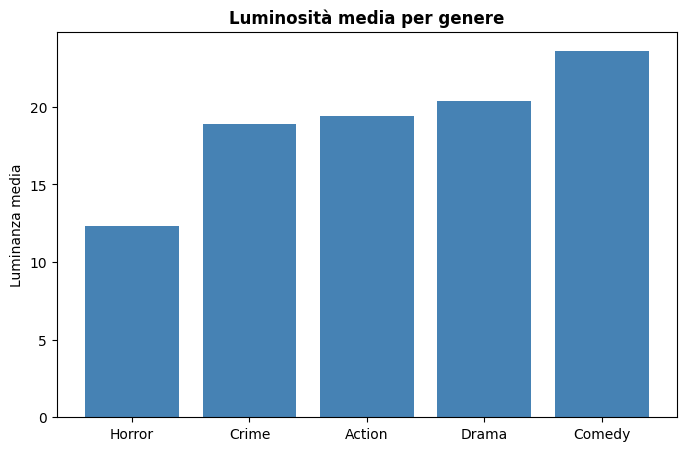

In [49]:
dati = media_per_genere.sort_values()
plt.figure(figsize=(8, 5))
plt.bar(dati.index, dati.values, color="steelblue")
plt.ylabel("Luminanza media")
plt.title("Luminosità media per genere", fontsize=12, fontweight="bold")
plt.savefig("../outputs/brightness_by_genre.png", dpi=100, bbox_inches="tight")
plt.show()

In [6]:
media_temp = colori_df.groupby("genere_principale")["temperature_media"].mean()
print("Temperatura media per genere (piu bassa = piu fredda):")
print(media_temp.sort_values())

Temperatura media per genere (piu bassa = piu fredda):
genere_principale
Horror    1.993415
Action    2.361827
Comedy    3.417414
Drama     3.698814
Crime     3.808459
Name: temperature_media, dtype: float64


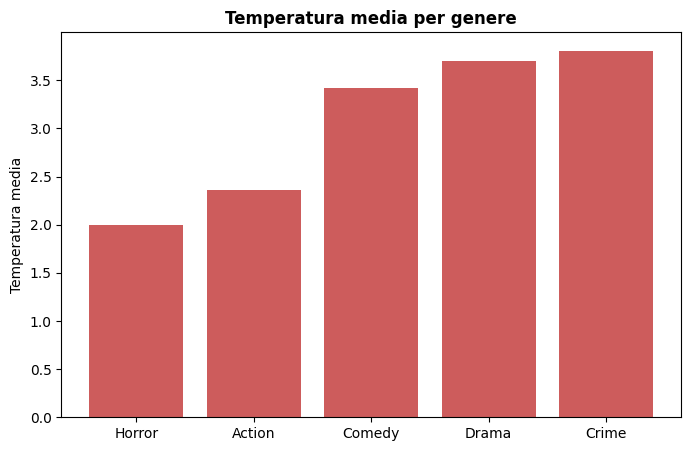

In [7]:
dati = media_temp.sort_values()
plt.figure(figsize=(8, 5))
plt.bar(dati.index, dati.values, color="indianred")
plt.ylabel("Temperatura media")
plt.title("Temperatura media per genere", fontsize=12, fontweight="bold")
plt.savefig("../outputs/temperature_by_genre.png", dpi=100, bbox_inches="tight")
plt.show()

Saturazione media per genere (piu bassa = piu smorto):
genere_principale
Drama     0.290731
Action    0.324680
Comedy    0.325201
Horror    0.334907
Crime     0.354571
Name: saturation_media, dtype: float64


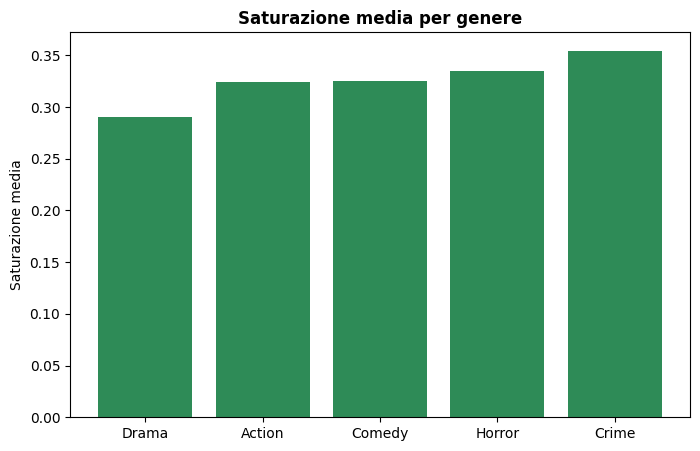

In [8]:
media_sat = colori_df.groupby("genere_principale")["saturation_media"].mean()
print("Saturazione media per genere (piu bassa = piu smorto):")
print(media_sat.sort_values())

dati = media_sat.sort_values()
plt.figure(figsize=(8, 5))
plt.bar(dati.index, dati.values, color="seagreen")
plt.ylabel("Saturazione media")
plt.title("Saturazione media per genere", fontsize=12, fontweight="bold")
plt.savefig("../outputs/saturation_by_genre.png", dpi=100, bbox_inches="tight")
plt.show()

## Il classificatore: come e' stato costruito, passo per passo

Due decisioni prese una alla volta:

**Fase 1** — quale misura di colore usare? Le medie o la distribuzione dei colori?

**Fase 2** — come gestire lo sbilanciamento di Action? Pesare le classi o ridurle fisicamente?

Solo dopo si costruisce il modello definitivo, arricchendolo con saturazione e filtro cartelli.

In [9]:
def confronta_due_versioni(nome1, acc1, cm1, nome2, acc2, cm2, titolo):
    """Disegna un confronto tra due versioni del classificatore: un
    grafico a barre con l'accuratezza, e una mini-heatmap con la
    percentuale di film indovinati correttamente per genere."""
    generi_cm = sorted(cm1.index.tolist())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 2]})

    ax1.bar([nome1, nome2], [acc1 * 100, acc2 * 100], color=["#6BAED6", "#E6550D"])
    ax1.set_ylabel("Accuratezza (%)")
    ax1.set_ylim(0, max(acc1, acc2) * 100 + 15)
    for i, v in enumerate([acc1, acc2]):
        ax1.text(i, v * 100 + 2, f"{v*100:.1f}%", ha="center", fontweight="bold")
    ax1.set_title("Accuratezza", fontsize=11, fontweight="bold")

    dati = []
    for cm in [cm1, cm2]:
        riga = []
        for g in generi_cm:
            totale = cm.loc[g].sum()
            corretti = cm.loc[g, g]
            riga.append((corretti / totale * 100) if totale > 0 else 0)
        dati.append(riga)
    dati = np.array(dati)

    im = ax2.imshow(dati, cmap=CMAP_CUSTOM, vmin=0, vmax=100, aspect="auto")
    ax2.set_xticks(range(len(generi_cm)))
    ax2.set_xticklabels(generi_cm)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels([nome1, nome2])
    ax2.set_xticks(np.arange(-0.5, len(generi_cm), 1), minor=True)
    ax2.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax2.grid(which="minor", color="white", linewidth=3)
    ax2.tick_params(which="minor", size=0)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    for i in range(2):
        for j in range(len(generi_cm)):
            v = dati[i, j]
            colore_testo = "white" if v < 30 or v > 80 else "#2b2b2b"
            ax2.text(j, i, f"{v:.0f}%", ha="center", va="center", color=colore_testo,
                      fontsize=10, fontweight="bold")
    ax2.set_title("% corretti per genere", fontsize=11, fontweight="bold")

    plt.suptitle(titolo, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [10]:
def valuta_con_cv(X, y, n_splits=5, random_state=42, **kwargs_modello):
    """Valuta un RandomForest con cross-validation stratificata invece di
    un singolo split. Ogni film finisce nel test set esattamente una volta
    (su fold diversi): la confusion matrix aggregata copre TUTTO il
    dataset, non solo un quarto. Molto piu' stabile quando, come qui, i
    singoli generi hanno poche decine di film.

    Ritorna: accuratezza media, deviazione standard tra i fold,
    confusion matrix aggregata (conteggi, non %), importanza media delle
    feature."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    generi = sorted(y.unique())
    cm_totale = pd.DataFrame(0, index=generi, columns=generi)
    accuratezze = []
    importanze_accumulate = None

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        modello = RandomForestClassifier(random_state=random_state, **kwargs_modello)
        modello.fit(X_train, y_train)
        previsioni = modello.predict(X_test)

        accuratezze.append(accuracy_score(y_test, previsioni))
        cm_fold = confusion_matrix(y_test, previsioni, labels=generi)
        cm_totale += pd.DataFrame(cm_fold, index=generi, columns=generi)

        if importanze_accumulate is None:
            importanze_accumulate = modello.feature_importances_.copy()
        else:
            importanze_accumulate += modello.feature_importances_

    acc_media = np.mean(accuratezze)
    acc_std = np.std(accuratezze)
    importanze_medie = pd.Series(importanze_accumulate / n_splits, index=X.columns).sort_values(ascending=False)
    return acc_media, acc_std, cm_totale, importanze_medie

### Fase 1 — Quale misura di colore usare?

Confronto ad armi pari: entrambe le versioni vengono ordinate per
`tconst` prima dello split, cosi' lo stesso `random_state=42` seleziona
davvero **gli stessi film** come test set in entrambi i casi. Nessun
bilanciamento delle classi in nessuna delle due, per isolare una sola
variabile: quale misura di colore funziona meglio.

In [11]:
# Versione A: le medie (4 feature)
colonne_media = ["brightness_media", "brightness_std", "temperature_media", "temperature_std"]

colori_df_ord = colori_df.sort_values("tconst").reset_index(drop=True)
X = colori_df_ord[colonne_media]
y = colori_df_ord["genere_principale"]

print("Film per genere (dataset completo):")
print(y.value_counts())
print()

acc_fase1_media, std_fase1_media, cm_fase1_media, imp_fase1_media = valuta_con_cv(X, y)

print("Accuratezza (medie, CV 5 fold):", round(acc_fase1_media * 100, 1),
      "% (+/-", round(std_fase1_media * 100, 1), "tra i fold)")

Film per genere (dataset completo):
genere_principale
Action    72
Crime     19
Horror    18
Comedy    13
Drama     11
Name: count, dtype: int64

Accuratezza (medie, CV 5 fold): 52.6 % (+/- 4.5 tra i fold)


In [12]:
# Distribuzione dei colori (7 famiglie di tinta) - calcolo per tutti i 133 film
distribuzioni = []
fatti = 0
for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    frames = extract_frames(cartella + "/" + nome_file, per_second=1)
    dist = color_distribution(frames)
    riga = {"tconst": tconst}
    for famiglia, perc in dist.items():
        riga[famiglia] = perc
    distribuzioni.append(riga)
    fatti += 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "...")

print("Finito!")
color_dist_df = pd.DataFrame(distribuzioni)

generi_tab = colori_df[["tconst", "genere_principale"]]
dist_con_genere = color_dist_df.merge(generi_tab, on="tconst")
dist_con_genere = dist_con_genere.sort_values("tconst").reset_index(drop=True)
famiglie = ["red", "orange", "yellow", "green", "blue", "purple", "dark_neutral"]

Fatti 20 ...
Fatti 40 ...
Fatti 60 ...
Fatti 80 ...
Fatti 100 ...
Fatti 120 ...
Finito!


                   red  orange  yellow  green  blue  purple  dark_neutral
genere_principale                                                        
Action             0.3     8.2     7.4   16.4   9.3     0.4          58.0
Comedy             0.0     4.4    10.9   30.6  11.2     0.0          42.9
Crime              0.3     5.6     7.5   19.5   9.2     0.0          57.9
Drama              0.1     3.6     7.6   16.0  18.6     0.2          53.9
Horror             0.1     2.7     3.9    9.2   5.9     0.4          77.7


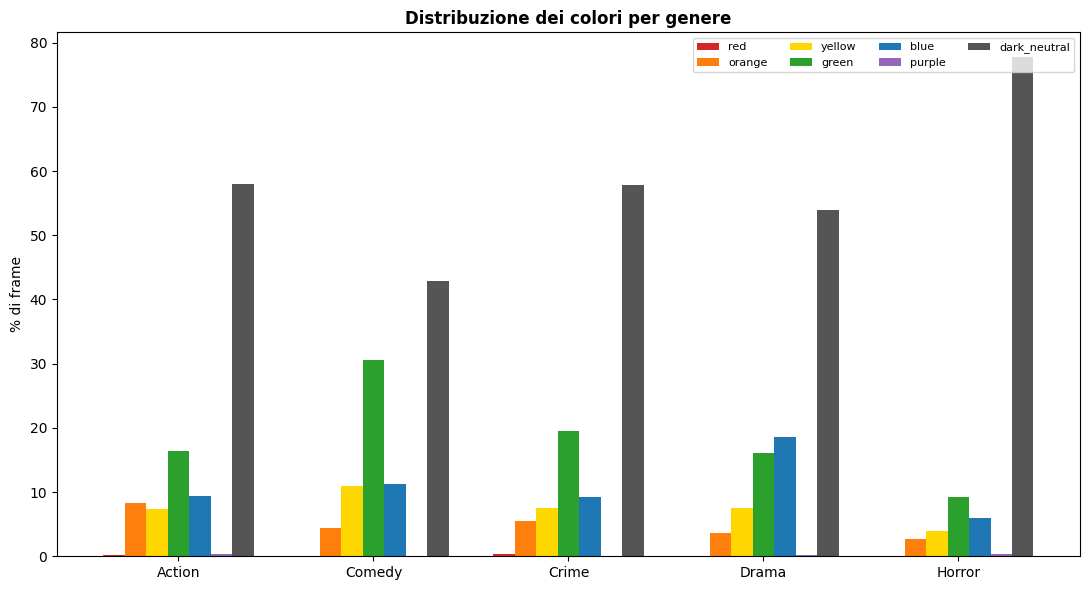

In [13]:
media_per_genere_dist = dist_con_genere.groupby("genere_principale")[famiglie].mean()
print((media_per_genere_dist * 100).round(1))

colori_barre = ["#D62728", "#FF7F0E", "#FFD700", "#2CA02C", "#1F77B4", "#9467BD", "#555555"]
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(media_per_genere_dist))
larghezza = 0.11
for i, famiglia in enumerate(famiglie):
    valori = media_per_genere_dist[famiglia].values * 100
    ax.bar(x + i * larghezza, valori, larghezza, label=famiglia, color=colori_barre[i])
ax.set_xticks(x + larghezza * 3)
ax.set_xticklabels(media_per_genere_dist.index)
ax.set_ylabel("% di frame")
ax.set_title("Distribuzione dei colori per genere", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, ncol=4, loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/color_distribution_by_genre.png", dpi=100, bbox_inches="tight")
plt.show()

In [14]:
X = dist_con_genere[famiglie]
y = dist_con_genere["genere_principale"]

acc_fase1_distribuzione, std_fase1_distribuzione, cm_fase1_distribuzione, imp_fase1_distribuzione = valuta_con_cv(X, y)

print("Accuratezza (distribuzione colori, CV 5 fold):", round(acc_fase1_distribuzione * 100, 1),
      "% (+/-", round(std_fase1_distribuzione * 100, 1), "tra i fold)")

Accuratezza (distribuzione colori, CV 5 fold): 52.6 % (+/- 5.0 tra i fold)


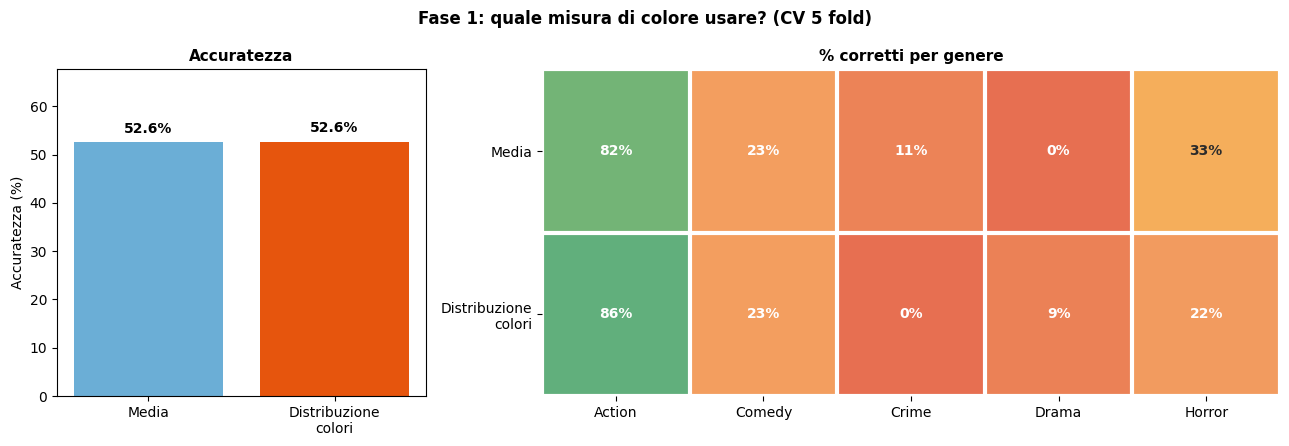

Come interpretare questo confronto:

- Il grafico a sinistra mostra l'accuratezza media su 5 fold di
  cross-validation (non un singolo split): con dataset piccoli come
  questo, un solo split al 25% lascia pochissimi film per genere nel
  test e il risultato varia parecchio a seconda di quali film ci
  capitano. La heatmap a destra e' calcolata sulla confusion matrix
  AGGREGATA su tutti i fold, quindi copre tutti i film del dataset.
- Se una versione ha accuratezza aggregata piu' alta ma perde (o
  pareggia) in OGNI genere preso singolarmente nella heatmap, quel
  numero aggregato e' probabilmente gonfiato dal peso di un genere
  numeroso (Action) nel campione - non un vantaggio reale.
- Conclusione: si sceglie la versione piu' equilibrata tra i
  generi, non solo quella con il numero aggregato piu' alto.


In [15]:
confronta_due_versioni("Media", acc_fase1_media, cm_fase1_media,
                         "Distribuzione\ncolori", acc_fase1_distribuzione, cm_fase1_distribuzione,
                         "Fase 1: quale misura di colore usare? (CV 5 fold)")

print("Come interpretare questo confronto:")
print()
print("- Il grafico a sinistra mostra l'accuratezza media su 5 fold di")
print("  cross-validation (non un singolo split): con dataset piccoli come")
print("  questo, un solo split al 25% lascia pochissimi film per genere nel")
print("  test e il risultato varia parecchio a seconda di quali film ci")
print("  capitano. La heatmap a destra e' calcolata sulla confusion matrix")
print("  AGGREGATA su tutti i fold, quindi copre tutti i film del dataset.")
print("- Se una versione ha accuratezza aggregata piu' alta ma perde (o")
print("  pareggia) in OGNI genere preso singolarmente nella heatmap, quel")
print("  numero aggregato e' probabilmente gonfiato dal peso di un genere")
print("  numeroso (Action) nel campione - non un vantaggio reale.")
print("- Conclusione: si sceglie la versione piu' equilibrata tra i")
print("  generi, non solo quella con il numero aggregato piu' alto.")

### Fase 2 — Come gestire lo sbilanciamento di Action?

Presa la decisione sulla Fase 1 (distribuzione dei colori), si
confronta come trattare i 72 film Action su 133: pesare le classi
durante l'addestramento, o ridurle fisicamente allo stesso numero
degli altri generi.

In [16]:
# Versione A: bilanciamento pesato (class_weight), su distribuzione colori
X = dist_con_genere[famiglie]
y = dist_con_genere["genere_principale"]

acc_fase2_bilanciato, std_fase2_bilanciato, cm_fase2_bilanciato, imp_fase2_bilanciato = valuta_con_cv(
    X, y, class_weight="balanced"
)

print("Accuratezza (bilanciato, pesato, CV 5 fold):", round(acc_fase2_bilanciato * 100, 1),
      "% (+/-", round(std_fase2_bilanciato * 100, 1), "tra i fold)")

Accuratezza (bilanciato, pesato, CV 5 fold): 50.4 % (+/- 4.4 tra i fold)


In [17]:
# Versione B: sottocampionamento fisico di Action
n_target = 18
action_ridotto = dist_con_genere[dist_con_genere["genere_principale"] == "Action"].sample(n=n_target, random_state=42)
altri_generi = dist_con_genere[dist_con_genere["genere_principale"] != "Action"]
dist_con_genere_bilanciato = pd.concat([action_ridotto, altri_generi])
dist_con_genere_bilanciato = dist_con_genere_bilanciato.sort_values("tconst").reset_index(drop=True)
print("Film per genere dopo il sottocampionamento:")
print(dist_con_genere_bilanciato["genere_principale"].value_counts())
print()

X = dist_con_genere_bilanciato[famiglie]
y = dist_con_genere_bilanciato["genere_principale"]

# n_splits=5 richiede almeno 5 film nella classe piu' piccola: verifichiamolo
n_min_classe = dist_con_genere_bilanciato["genere_principale"].value_counts().min()
n_splits_sicuro = min(5, n_min_classe)
if n_splits_sicuro < 5:
    print(f"Attenzione: la classe piu' piccola ha solo {n_min_classe} film, uso {n_splits_sicuro} fold invece di 5.")

acc_fase2_sottocampionato, std_fase2_sottocampionato, cm_fase2_sottocampionato, imp_fase2_sottocampionato = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (sottocampionato, 79 film, CV", n_splits_sicuro, "fold):", round(acc_fase2_sottocampionato * 100, 1),
      "% (+/-", round(std_fase2_sottocampionato * 100, 1), "tra i fold)")
print("Nota: usa meno dati (79 film, non 133) - confronto indicativo.")

Film per genere dopo il sottocampionamento:
genere_principale
Crime     19
Horror    18
Action    18
Comedy    13
Drama     11
Name: count, dtype: int64

Accuratezza (sottocampionato, 79 film, CV 5 fold): 31.8 % (+/- 7.9 tra i fold)
Nota: usa meno dati (79 film, non 133) - confronto indicativo.


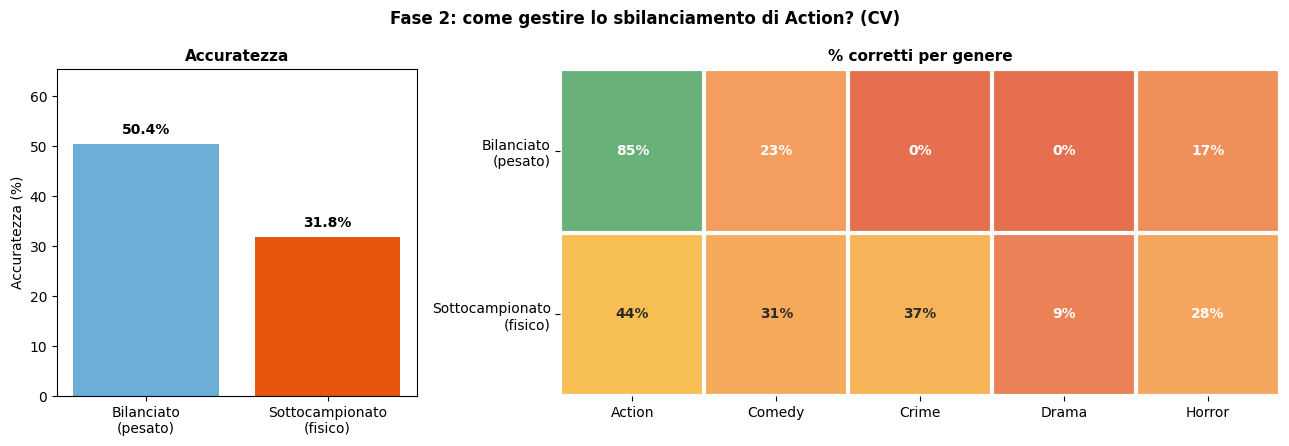

Come interpretare questo confronto:

- Anche qui le percentuali vengono da confusion matrix aggregate su
  piu' fold di CV, non da un singolo split: piu' stabili, meno
  sensibili a quali 3-4 film Action finiscono per caso nel test.
- Guarda la colonna Action nella heatmap: se il Bilanciato mostra
  una percentuale molto alta li' e vicina a 0% negli altri generi,
  il modello si sta 'rifugiando' in Action nonostante il peso.
- Se il Sottocampionato mostra percentuali piu' basse su Action ma
  NESSUN genere a 0%, sta riconoscendo qualcosa ovunque, anche se
  l'accuratezza complessiva e' piu' bassa.
- Conclusione: si sceglie il metodo che distribuisce meglio il
  riconoscimento tra i generi, anche a costo di un'accuratezza
  aggregata piu' bassa - un modello che indovina 'sempre lo stesso
  genere' non e' utile, anche se il numero sembra buono.


In [18]:
confronta_due_versioni("Bilanciato\n(pesato)", acc_fase2_bilanciato, cm_fase2_bilanciato,
                         "Sottocampionato\n(fisico)", acc_fase2_sottocampionato, cm_fase2_sottocampionato,
                         "Fase 2: come gestire lo sbilanciamento di Action? (CV)")

print("Come interpretare questo confronto:")
print()
print("- Anche qui le percentuali vengono da confusion matrix aggregate su")
print("  piu' fold di CV, non da un singolo split: piu' stabili, meno")
print("  sensibili a quali 3-4 film Action finiscono per caso nel test.")
print("- Guarda la colonna Action nella heatmap: se il Bilanciato mostra")
print("  una percentuale molto alta li' e vicina a 0% negli altri generi,")
print("  il modello si sta 'rifugiando' in Action nonostante il peso.")
print("- Se il Sottocampionato mostra percentuali piu' basse su Action ma")
print("  NESSUN genere a 0%, sta riconoscendo qualcosa ovunque, anche se")
print("  l'accuratezza complessiva e' piu' bassa.")
print("- Conclusione: si sceglie il metodo che distribuisce meglio il")
print("  riconoscimento tra i generi, anche a costo di un'accuratezza")
print("  aggregata piu' bassa - un modello che indovina 'sempre lo stesso")
print("  genere' non e' utile, anche se il numero sembra buono.")

### Fase 3 — Costruzione del modello definitivo

Base scelta: distribuzione dei colori, sottocampionamento fisico di
Action (79 film). Ogni passo successivo lavora sullo stesso
sottoinsieme di film, cosi' i confronti restano puliti.

In [19]:
acc_base_fase3 = acc_fase2_sottocampionato
cm_base_fase3 = cm_fase2_sottocampionato
print("Punto di partenza (Sottocampionato, distribuzione colori):", round(acc_base_fase3 * 100, 1), "%")

Punto di partenza (Sottocampionato, distribuzione colori): 31.8 %


In [20]:
# + Saturazione
info_saturazione = colori_df[["tconst", "saturation_media", "saturation_std"]]
dist_bilanciato_sat = dist_con_genere_bilanciato.merge(info_saturazione, on="tconst")

famiglie_piu_saturazione = famiglie + ["saturation_media", "saturation_std"]

X = dist_bilanciato_sat[famiglie_piu_saturazione]
y = dist_bilanciato_sat["genere_principale"]

acc_saturazione, std_saturazione, cm_saturazione, imp_saturazione = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (+ saturazione, CV", n_splits_sicuro, "fold):", round(acc_saturazione * 100, 1),
      "% (+/-", round(std_saturazione * 100, 1), "tra i fold)")
print("(prima, sottocampionato senza saturazione:", round(acc_base_fase3 * 100, 1), "%)")
print()
print("Importanza media delle feature (quanto pesano nelle decisioni del modello):")
print(imp_saturazione)
print()
print("Se saturation_media/saturation_std sono in cima alla lista, il modello")
print("si appoggia molto su quelle due feature - vale la pena confrontarle con")
print("il grafico 'Saturazione media per genere' piu' sopra: se Action e Horror")
print("hanno saturazione simile, e' li' che nasce la confusione tra i due.")

Accuratezza (+ saturazione, CV 5 fold): 34.2 % (+/- 9.6 tra i fold)
(prima, sottocampionato senza saturazione: 31.8 %)

Importanza media delle feature (quanto pesano nelle decisioni del modello):
saturation_std      0.161956
dark_neutral        0.159593
yellow              0.148433
green               0.136684
blue                0.136682
saturation_media    0.124021
orange              0.101059
purple              0.021313
red                 0.010259
dtype: float64

Se saturation_media/saturation_std sono in cima alla lista, il modello
si appoggia molto su quelle due feature - vale la pena confrontarle con
il grafico 'Saturazione media per genere' piu' sopra: se Action e Horror
hanno saturazione simile, e' li' che nasce la confusione tra i due.


#### Filtro dei frame-cartello

Criterio adattivo: si cammina dall'inizio del trailer finche' i frame
restano uniformi (stesso colore dominante, anche con del testo sopra),
ci si ferma alla prima scena vera. Stessa cosa dalla fine. Nessuna
finestra fissa di secondi da indovinare.

In [21]:
def e_uniforme(frame, soglia_frazione=0.55):
    """Un frame e' uniforme se una grande % dei suoi pixel e' vicina al
    colore mediano (sfondo piatto, anche con del testo/logo sopra)."""
    pixel = frame.reshape(-1, 3).astype(float)
    colore_mediano = np.median(pixel, axis=0)
    distanze = np.sqrt(((pixel - colore_mediano) ** 2).sum(axis=1))
    frazione_uniforme = (distanze < 30).mean()
    return frazione_uniforme > soglia_frazione

def trova_frame_cartello(frames):
    """Cammina dall'inizio e dalla fine del trailer, marcando come 'cartello'
    i frame uniformi consecutivi, finche' non trova una scena vera."""
    n = len(frames)
    da_scartare = set()
    i = 0
    while i < n and e_uniforme(frames[i]):
        da_scartare.add(i)
        i += 1
    j = n - 1
    while j >= 0 and j not in da_scartare and e_uniforme(frames[j]):
        da_scartare.add(j)
        j -= 1
    return da_scartare

In [ ]:
# ricalcoliamo la distribuzione colori E le statistiche di luminanza/
# temperatura escludendo i frame-cartello, per i 79 film del sottoinsieme.
# Un solo passaggio sui frame per entrambe le catene (Distribuzione e Media),
# per non estrarre i frame due volte - l'estrazione video e' il passo lento.
#
# Firma confermata in src/metrics.py:
#   curve_from_frames(frames) -> (brightness, temperature, saturation, colours)
tconst_da_processare = set(dist_bilanciato_sat["tconst"].tolist())

distribuzioni_filtrate = []
brightness_temp_filtrate = []
fatti = 0
for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    if tconst not in tconst_da_processare:
        continue

    frames = extract_frames(cartella + "/" + nome_file, per_second=1)
    indici_cartello = trova_frame_cartello(frames)

    frames_puliti = []
    for i in range(len(frames)):
        if i not in indici_cartello:
            frames_puliti.append(frames[i])
    if len(frames_puliti) == 0:
        frames_puliti = frames

    dist = color_distribution(frames_puliti)
    riga = {"tconst": tconst}
    for famiglia, perc in dist.items():
        riga[famiglia] = perc
    distribuzioni_filtrate.append(riga)

    curva_brightness, curva_temperature, curva_saturation, _ = curve_from_frames(frames_puliti)
    brightness_temp_filtrate.append({
        "tconst": tconst,
        "brightness_media": np.mean(curva_brightness),
        "brightness_std": np.std(curva_brightness),
        "temperature_media": np.mean(curva_temperature),
        "temperature_std": np.std(curva_temperature),
        # bonus: saturazione ricalcolata SUI FRAME PULITI (senza cartelli),
        # a differenza di saturation_media/std nel warehouse che sono
        # calcolate su tutti i frame, cartelli compresi
        "saturation_media_filtrata": np.mean(curva_saturation),
        "saturation_std_filtrata": np.std(curva_saturation),
    })

    fatti += 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "...")

print("Finito!")
color_dist_filtrato_df = pd.DataFrame(distribuzioni_filtrate).sort_values("tconst").reset_index(drop=True)
brightness_temp_filtrato_df = pd.DataFrame(brightness_temp_filtrate).sort_values("tconst").reset_index(drop=True)

dist_filtrato_completo = color_dist_filtrato_df.merge(info_saturazione, on="tconst")
dist_filtrato_completo = dist_filtrato_completo.merge(
    dist_bilanciato_sat[["tconst", "genere_principale"]], on="tconst"
)

media_filtrato_completo = brightness_temp_filtrato_df.merge(info_saturazione, on="tconst")
media_filtrato_completo = media_filtrato_completo.merge(
    dist_bilanciato_sat[["tconst", "genere_principale"]], on="tconst"
)


Fatti 20 ...
Fatti 40 ...
Fatti 60 ...
Finito!


In [ ]:
X = dist_filtrato_completo[famiglie_piu_saturazione]
y = dist_filtrato_completo["genere_principale"]

acc_filtro, std_filtro, cm_filtro, imp_filtro = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (+ filtro cartelli, CV", n_splits_sicuro, "fold):", round(acc_filtro * 100, 1),
      "% (+/-", round(std_filtro * 100, 1), "tra i fold)")
print("(prima, con saturazione:", round(acc_saturazione * 100, 1), "%)")

Accuratezza (+ filtro cartelli, CV 5 fold): 34.4 % (+/- 10.5 tra i fold)
(prima, con saturazione: 34.2 %)


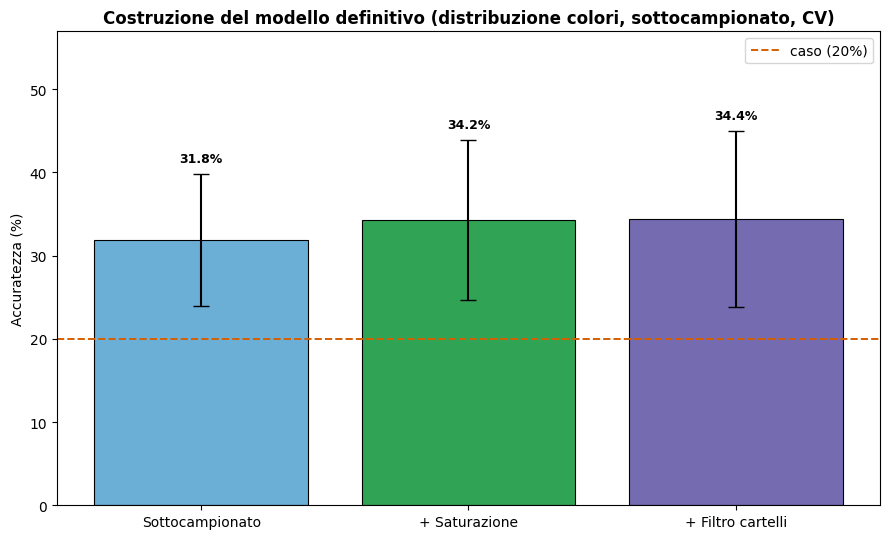

Nota: questa catena usa 79 film (Action ridotto a 18), non 133 -
coerente con la scelta del Sottocampionato nella Fase 2.
Le barre d'errore mostrano la deviazione standard tra i 5 fold di CV:
barre piu' lunghe = risultato meno stabile, da prendere con piu' cautela.


In [ ]:
risultati_finali = {
    "Sottocampionato": (acc_base_fase3, std_fase2_sottocampionato),
    "+ Saturazione": (acc_saturazione, std_saturazione),
    "+ Filtro cartelli": (acc_filtro, std_filtro),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
nomi = list(risultati_finali.keys())
valori = [v[0] * 100 for v in risultati_finali.values()]
errori = [v[1] * 100 for v in risultati_finali.values()]
colori_barre_ris = ["#6BAED6", "#31A354", "#756BB1"]

barre = ax.bar(nomi, valori, yerr=errori, capsize=6, color=colori_barre_ris, edgecolor="black", linewidth=0.8)
ax.axhline(20, color="#D55E00", linestyle="--", linewidth=1.4, label="caso (20%)")
ax.set_ylabel("Accuratezza (%)")
ax.set_title("Costruzione del modello definitivo (distribuzione colori, sottocampionato, CV)", fontsize=12, fontweight="bold")
ax.legend()
ax.set_ylim(0, max(valori) + max(errori) + 12)
for barra, val, err in zip(barre, valori, errori):
    ax.text(barra.get_x() + barra.get_width()/2, val + err + 1.5, f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/classifier_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

print("Nota: questa catena usa 79 film (Action ridotto a 18), non 133 -")
print("coerente con la scelta del Sottocampionato nella Fase 2.")
print("Le barre d'errore mostrano la deviazione standard tra i", n_splits_sicuro, "fold di CV:")
print("barre piu' lunghe = risultato meno stabile, da prendere con piu' cautela.")


### Isolare la causa: saturazione o filtro cartelli?

Nella catena definitiva le due modifiche si sommano, quindi da sole
le due barre precedenti non dicono quale delle due causi il calo di
Action osservato in fase di analisi. Qui si isola ciascun contributo
separatamente, partendo sempre dalla stessa base (Sottocampionato,
senza saturazione ne' filtro).

In [ ]:
# Solo saturazione (nessun filtro cartelli) - identico al modello "+ Saturazione" sopra
acc_solo_saturazione, cm_solo_saturazione = acc_saturazione, cm_saturazione

# Solo filtro cartelli (nessuna saturazione): stessi frame puliti, ma senza le due colonne di saturazione
dist_filtrato_solo_colori = color_dist_filtrato_df.merge(
    dist_bilanciato_sat[["tconst", "genere_principale"]], on="tconst"
)

X = dist_filtrato_solo_colori[famiglie]
y = dist_filtrato_solo_colori["genere_principale"]

acc_solo_filtro, std_solo_filtro, cm_solo_filtro, imp_solo_filtro = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (solo filtro cartelli, no saturazione, CV", n_splits_sicuro, "fold):",
      round(acc_solo_filtro * 100, 1), "%")
print("Accuratezza (solo saturazione, no filtro, CV", n_splits_sicuro, "fold):",
      round(acc_solo_saturazione * 100, 1), "%")
print("Base (nessuna delle due, CV", n_splits_sicuro, "fold):", round(acc_base_fase3 * 100, 1), "%")


Accuratezza (solo filtro cartelli, no saturazione, CV 5 fold): 31.8 %
Accuratezza (solo saturazione, no filtro, CV 5 fold): 34.2 %
Base (nessuna delle due, CV 5 fold): 31.8 %


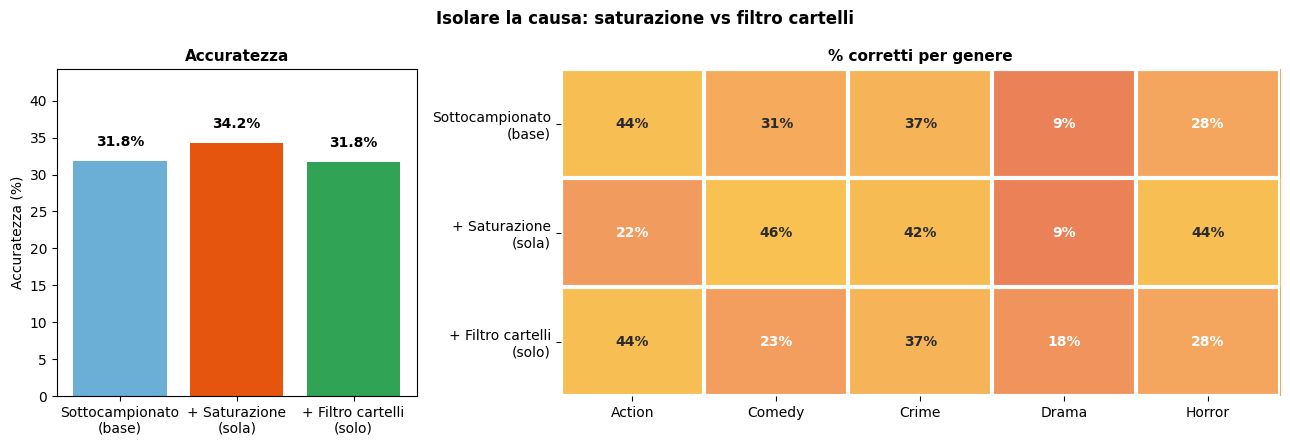

Guarda la colonna Action: se crolla solo nella riga '+ Saturazione (sola)'
e resta piu' alta in '+ Filtro cartelli (solo)', la saturazione e' la causa
isolata del problema, non un effetto combinato con il filtro.


In [ ]:
confronti_isolati = {
    "Sottocampionato\n(base)": (acc_base_fase3, cm_base_fase3),
    "+ Saturazione\n(sola)": (acc_solo_saturazione, cm_solo_saturazione),
    "+ Filtro cartelli\n(solo)": (acc_solo_filtro, cm_solo_filtro),
}

generi_isolati = sorted(cm_base_fase3.index.tolist())
righe = []
for nome, (acc, cm) in confronti_isolati.items():
    riga = []
    for g in generi_isolati:
        totale = cm.loc[g].sum()
        corretti = cm.loc[g, g]
        riga.append((corretti / totale * 100) if totale > 0 else 0)
    righe.append(riga)
dati_isolati = np.array(righe)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 2]})
nomi_i = list(confronti_isolati.keys())
valori_i = [v[0] * 100 for v in confronti_isolati.values()]
ax1.bar(nomi_i, valori_i, color=["#6BAED6", "#E6550D", "#31A354"])
ax1.set_ylabel("Accuratezza (%)")
ax1.set_title("Accuratezza", fontsize=11, fontweight="bold")
ax1.set_ylim(0, max(valori_i) + 10)
for i, v in enumerate(valori_i):
    ax1.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

im = ax2.imshow(dati_isolati, cmap=CMAP_CUSTOM, vmin=0, vmax=100, aspect="auto")
ax2.set_xticks(range(len(generi_isolati)))
ax2.set_xticklabels(generi_isolati)
ax2.set_yticks(range(3))
ax2.set_yticklabels(nomi_i)
ax2.set_xticks(np.arange(-0.5, len(generi_isolati), 1), minor=True)
ax2.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax2.grid(which="minor", color="white", linewidth=3)
ax2.tick_params(which="minor", size=0)
for spine in ax2.spines.values():
    spine.set_visible(False)
for i in range(3):
    for j in range(len(generi_isolati)):
        v = dati_isolati[i, j]
        colore_testo = "white" if v < 30 or v > 80 else "#2b2b2b"
        ax2.text(j, i, f"{v:.0f}%", ha="center", va="center", color=colore_testo, fontsize=10, fontweight="bold")
ax2.set_title("% corretti per genere", fontsize=11, fontweight="bold")
plt.suptitle("Isolare la causa: saturazione vs filtro cartelli", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/isolamento_saturazione_filtro.png", dpi=100, bbox_inches="tight")
plt.show()

print("Guarda la colonna Action: se crolla solo nella riga '+ Saturazione (sola)'")
print("e resta piu' alta in '+ Filtro cartelli (solo)', la saturazione e' la causa")
print("isolata del problema, non un effetto combinato con il filtro.")


### Importanza delle feature: cosa guarda il modello con la saturazione?

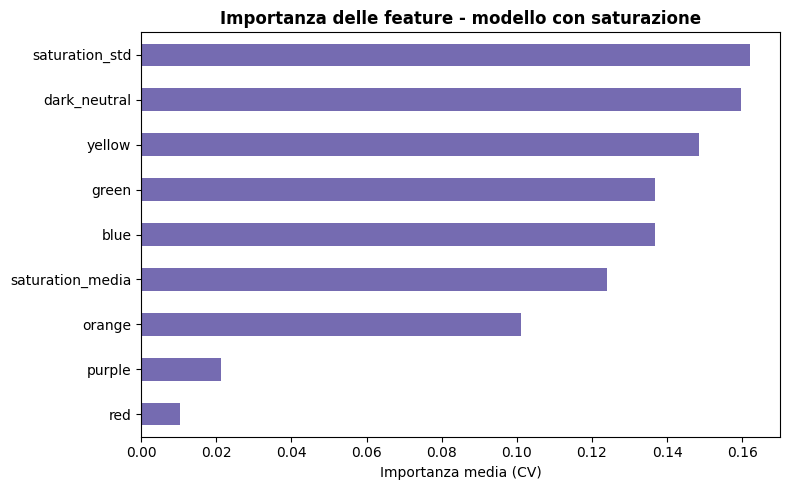

Se saturation_media / saturation_std sono in cima alla lista, il
modello si affida molto a quelle due feature per distinguere i generi -
da confrontare con il grafico 'Saturazione media per genere' piu' sopra.


In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
imp_saturazione.sort_values().plot(kind="barh", ax=ax, color="#756BB1")
ax.set_xlabel("Importanza media (CV)")
ax.set_title("Importanza delle feature - modello con saturazione", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/feature_importance_saturazione.png", dpi=100, bbox_inches="tight")
plt.show()

print("Se saturation_media / saturation_std sono in cima alla lista, il")
print("modello si affida molto a quelle due feature per distinguere i generi -")
print("da confrontare con il grafico 'Saturazione media per genere' piu' sopra.")


## Catena alternativa: Media dei colori

Con la cross-validation, la Fase 1 e' risultata un sostanziale pareggio
(52.6% vs 52.6%, equilibrio tra generi leggermente a favore di Media),
non piu' una vittoria netta di Distribuzione come con lo split singolo.
Invece di scartare Media, si ricostruisce qui l'intera catena (Fase 2 +
Fase 3) anche per questa opzione, usando **lo stesso sottoinsieme di 79
film** (stessi 18 Action, gia' campionati sopra) cosi' il confronto finale
tra le due catene complete e' ad armi pari.

### Fase 2 (Media) — bilanciamento vs sottocampionamento

In [28]:
# Versione A: bilanciamento pesato, su Media, tutti i 133 film
X = colori_df_ord[colonne_media]
y = colori_df_ord["genere_principale"]

acc_fase2_bilanciato_media, std_fase2_bilanciato_media, cm_fase2_bilanciato_media, imp_fase2_bilanciato_media = valuta_con_cv(
    X, y, class_weight="balanced"
)

print("Accuratezza (Media, bilanciato pesato, CV 5 fold):", round(acc_fase2_bilanciato_media * 100, 1),
      "% (+/-", round(std_fase2_bilanciato_media * 100, 1), "tra i fold)")

Accuratezza (Media, bilanciato pesato, CV 5 fold): 51.1 % (+/- 0.9 tra i fold)


In [29]:
# Versione B: sottocampionamento fisico di Action - STESSI 18 film gia'
# selezionati sopra per la catena Distribuzione (stesso tconst), per un
# confronto ad armi pari tra le due catene complete.
colori_df_bilanciato = colori_df_ord[
    colori_df_ord["tconst"].isin(dist_con_genere_bilanciato["tconst"])
].reset_index(drop=True)

print("Film per genere dopo il sottocampionamento (Media):")
print(colori_df_bilanciato["genere_principale"].value_counts())

X = colori_df_bilanciato[colonne_media]
y = colori_df_bilanciato["genere_principale"]

acc_fase2_sottocampionato_media, std_fase2_sottocampionato_media, cm_fase2_sottocampionato_media, imp_fase2_sottocampionato_media = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (Media, sottocampionato, CV", n_splits_sicuro, "fold):", round(acc_fase2_sottocampionato_media * 100, 1),
      "% (+/-", round(std_fase2_sottocampionato_media * 100, 1), "tra i fold)")

Film per genere dopo il sottocampionamento (Media):
genere_principale
Crime     19
Horror    18
Action    18
Comedy    13
Drama     11
Name: count, dtype: int64
Accuratezza (Media, sottocampionato, CV 5 fold): 34.2 % (+/- 5.5 tra i fold)


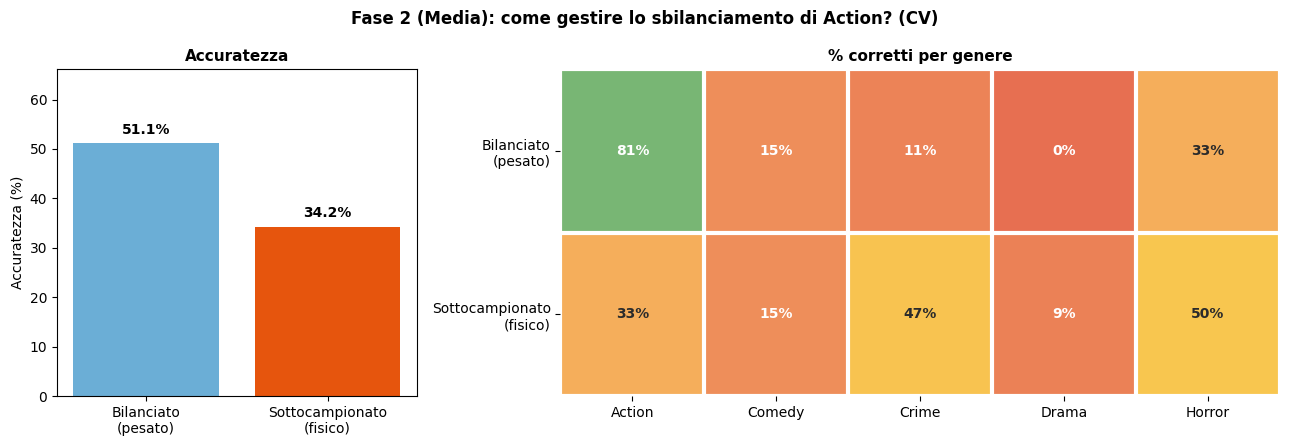

In [30]:
confronta_due_versioni("Bilanciato\n(pesato)", acc_fase2_bilanciato_media, cm_fase2_bilanciato_media,
                         "Sottocampionato\n(fisico)", acc_fase2_sottocampionato_media, cm_fase2_sottocampionato_media,
                         "Fase 2 (Media): come gestire lo sbilanciamento di Action? (CV)")

### La differenza tra le due catene è statisticamente significativa?

A questo punto entrambe le catene hanno completato la Fase 2 con
Sottocampionato. Prima di continuare a costruire la Fase 3 per entrambe,
si formalizza la domanda: la differenza osservata (Distribuzione vs
Media) è reale o rientra nel rumore campionario? Si usa un **paired
t-test** (più un test di Wilcoxon di controllo) sugli stessi fold di CV,
per un confronto appaiato film-per-film invece che solo tra medie
aggregate.

In [31]:
from scipy import stats

def confronta_significativita(df1, features1, df2, features2, target_col="genere_principale",
                                n_splits=5, random_state=42, kwargs1=None, kwargs2=None):
    """Confronta due rappresentazioni di feature sullo STESSO sottoinsieme di
    film (identificato da tconst), usando gli stessi fold di CV per
    entrambe - permette un confronto appaiato (paired), non solo aggregato.
    """
    kwargs1 = kwargs1 or {}
    kwargs2 = kwargs2 or {}

    d1 = df1.sort_values("tconst").reset_index(drop=True)
    d2 = df2.sort_values("tconst").reset_index(drop=True)
    assert (d1["tconst"].values == d2["tconst"].values).all(), \
        "I due dataframe devono contenere esattamente gli stessi film, nello stesso ordine"

    X1 = d1[features1]
    X2 = d2[features2]
    y = d1[target_col]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    acc1_folds, acc2_folds = [], []

    for train_idx, test_idx in skf.split(X1, y):
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        m1 = RandomForestClassifier(random_state=random_state, **kwargs1)
        m1.fit(X1.iloc[train_idx], y_train)
        acc1_folds.append(accuracy_score(y_test, m1.predict(X1.iloc[test_idx])))

        m2 = RandomForestClassifier(random_state=random_state, **kwargs2)
        m2.fit(X2.iloc[train_idx], y_train)
        acc2_folds.append(accuracy_score(y_test, m2.predict(X2.iloc[test_idx])))

    acc1_folds = np.array(acc1_folds)
    acc2_folds = np.array(acc2_folds)
    diff = acc1_folds - acc2_folds

    t_stat, p_value_t = stats.ttest_rel(acc1_folds, acc2_folds)
    try:
        w_stat, p_value_w = stats.wilcoxon(acc1_folds, acc2_folds)
    except ValueError:
        w_stat, p_value_w = np.nan, np.nan

    return acc1_folds, acc2_folds, diff, t_stat, p_value_t, p_value_w

In [32]:
acc1_folds, acc2_folds, diff, t_stat, p_value_t, p_value_w = confronta_significativita(
    dist_con_genere_bilanciato, famiglie,
    colori_df_bilanciato, colonne_media,
    n_splits=n_splits_sicuro,
)

print("Accuratezza per fold - Distribuzione:", np.round(acc1_folds * 100, 1))
print("Accuratezza per fold - Media:        ", np.round(acc2_folds * 100, 1))
print("Differenza per fold (Distr. - Media):", np.round(diff * 100, 1))
print()
print(f"Differenza media: {diff.mean() * 100:.1f} punti percentuali")
print(f"Paired t-test:    t = {t_stat:.2f}, p = {p_value_t:.3f}")
print(f"Wilcoxon test:    p = {p_value_w:.3f}")
print()

alpha = 0.05
if p_value_t < alpha:
    print(f"p < {alpha}: la differenza è statisticamente significativa.")
    print("Si può scegliere la catena Distribuzione qui e fermarsi,")
    print("senza costruire la catena Media fino in fondo.")
else:
    print(f"p >= {alpha}: la differenza NON è statisticamente significativa")
    print(f"(con soli {n_splits_sicuro} fold, il test ha poca potenza statistica).")
    print("Non si può escludere che sia rumore campionario: si giustifica")
    print("costruire entrambe le catene fino in fondo per verificare se il")
    print("vantaggio si conferma o si inverte negli step successivi (fatto")
    print("qui sotto, nella Fase 3 di entrambe le catene).")

Accuratezza per fold - Distribuzione: [31.2 25.  25.  31.2 46.7]
Accuratezza per fold - Media:         [37.5 31.2 37.5 25.  40. ]
Differenza per fold (Distr. - Media): [ -6.2  -6.2 -12.5   6.2   6.7]

Differenza media: -2.4 punti percentuali
Paired t-test:    t = -0.64, p = 0.559
Wilcoxon test:    p = 0.812

p >= 0.05: la differenza NON è statisticamente significativa
(con soli 5 fold, il test ha poca potenza statistica).
Non si può escludere che sia rumore campionario: si giustifica
costruire entrambe le catene fino in fondo per verificare se il
vantaggio si conferma o si inverte negli step successivi (fatto
qui sotto, nella Fase 3 di entrambe le catene).


### Fase 3 (Media) — costruzione della catena, stesso ordine della catena Distribuzione

In [33]:
acc_base_fase3_media = acc_fase2_sottocampionato_media
std_base_fase3_media = std_fase2_sottocampionato_media
cm_base_fase3_media = cm_fase2_sottocampionato_media
print("Punto di partenza (Sottocampionato, Media):", round(acc_base_fase3_media * 100, 1), "%")

Punto di partenza (Sottocampionato, Media): 34.2 %


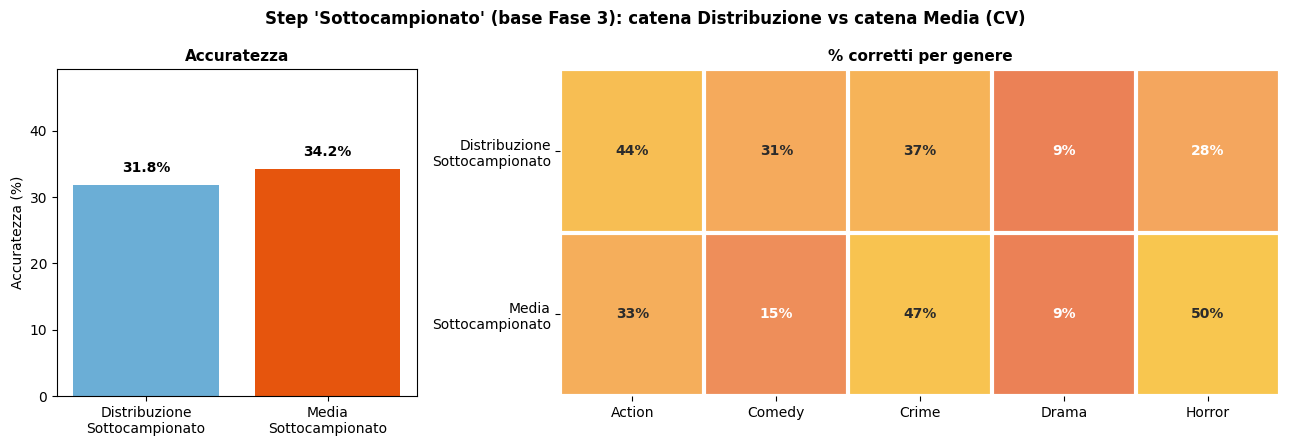

In [34]:
confronta_due_versioni("Distribuzione\nSottocampionato", acc_base_fase3, cm_base_fase3,
                         "Media\nSottocampionato", acc_base_fase3_media, cm_base_fase3_media,
                         "Step 'Sottocampionato' (base Fase 3): catena Distribuzione vs catena Media (CV)")

In [ ]:
# + Saturazione (Media)
colonne_media_piu_saturazione = colonne_media + ["saturation_media", "saturation_std"]

X = colori_df_bilanciato[colonne_media_piu_saturazione]
y = colori_df_bilanciato["genere_principale"]

acc_saturazione_media, std_saturazione_media, cm_saturazione_media, imp_saturazione_media = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (Media + saturazione, CV", n_splits_sicuro, "fold):", round(acc_saturazione_media * 100, 1),
      "% (+/-", round(std_saturazione_media * 100, 1), "tra i fold)")
print()
print("Importanza media delle feature:")
print(imp_saturazione_media)

Accuratezza (Media + saturazione, CV 5 fold): 35.4 % (+/- 6.2 tra i fold)

Importanza media delle feature:
brightness_media     0.211078
saturation_std       0.177197
temperature_media    0.163463
temperature_std      0.161507
saturation_media     0.148654
brightness_std       0.138100
dtype: float64


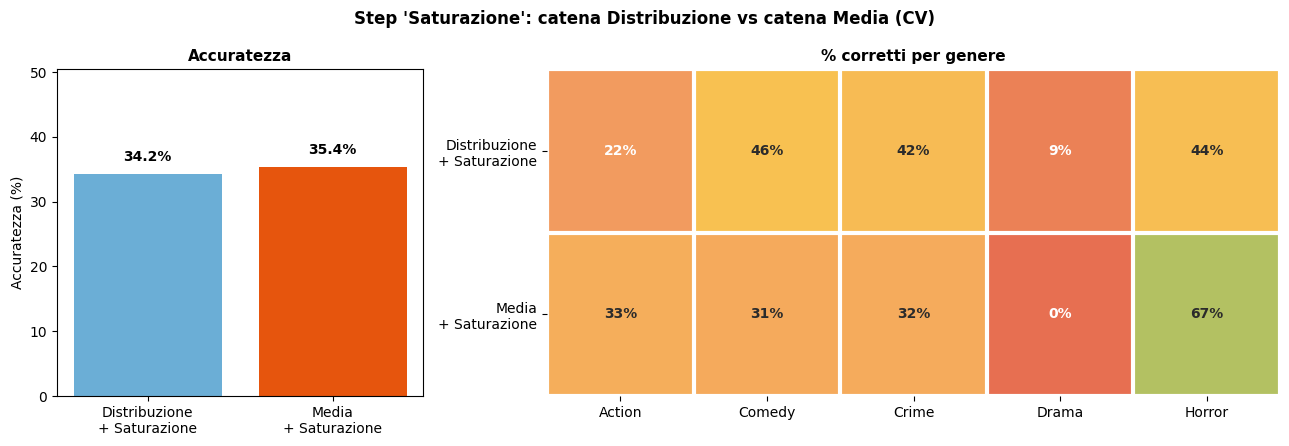

In [ ]:
confronta_due_versioni("Distribuzione\n+ Saturazione", acc_saturazione, cm_saturazione,
                         "Media\n+ Saturazione", acc_saturazione_media, cm_saturazione_media,
                         "Step 'Saturazione': catena Distribuzione vs catena Media (CV)")

In [ ]:
# + Filtro cartelli (Media) - usa media_filtrato_completo, calcolato nello
# stesso ciclo di estrazione della catena Distribuzione piu' sopra.
X = media_filtrato_completo[colonne_media_piu_saturazione]
y = media_filtrato_completo["genere_principale"]

acc_filtro_media, std_filtro_media, cm_filtro_media, imp_filtro_media = valuta_con_cv(
    X, y, n_splits=n_splits_sicuro
)

print("Accuratezza (Media + filtro cartelli, CV", n_splits_sicuro, "fold):", round(acc_filtro_media * 100, 1),
      "% (+/-", round(std_filtro_media * 100, 1), "tra i fold)")
print("(prima, con saturazione:", round(acc_saturazione_media * 100, 1), "%)")

Accuratezza (Media + filtro cartelli, CV 5 fold): 38.2 % (+/- 15.9 tra i fold)
(prima, con saturazione: 35.4 %)


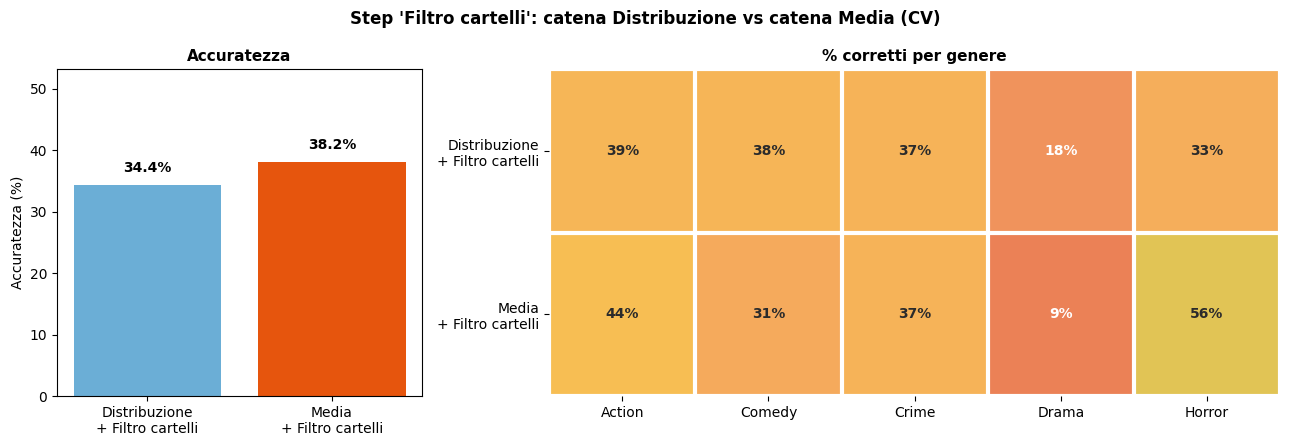

In [ ]:
confronta_due_versioni("Distribuzione\n+ Filtro cartelli", acc_filtro, cm_filtro,
                         "Media\n+ Filtro cartelli", acc_filtro_media, cm_filtro_media,
                         "Step 'Filtro cartelli': catena Distribuzione vs catena Media (CV)")

## Confronto finale: catena Distribuzione vs catena Media

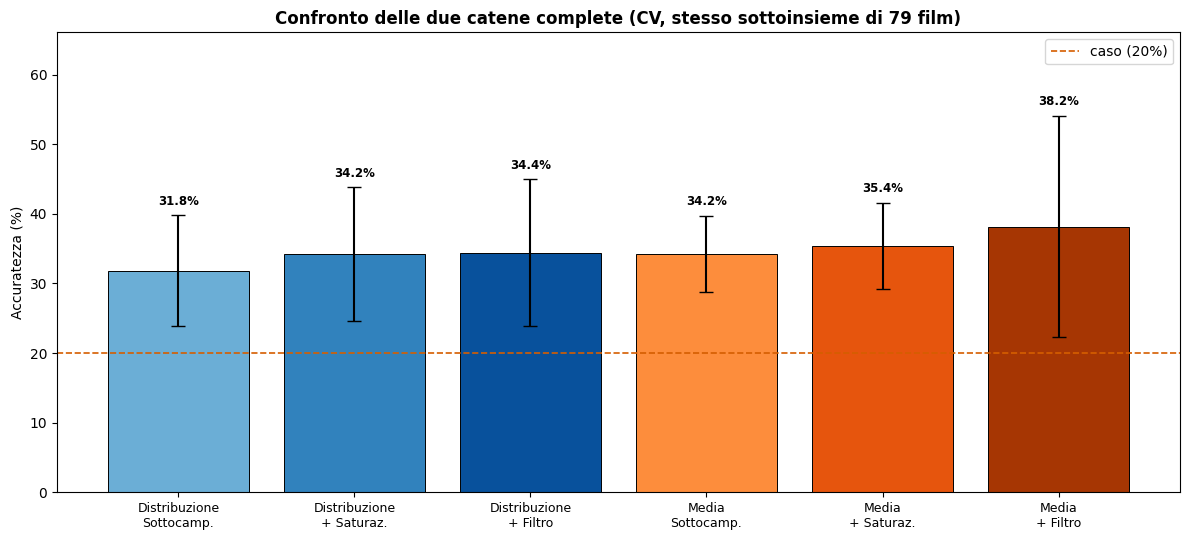

In [ ]:
confronto_catene = {
    "Distribuzione\nSottocamp.": (acc_base_fase3, std_fase2_sottocampionato),
    "Distribuzione\n+ Saturaz.": (acc_saturazione, std_saturazione),
    "Distribuzione\n+ Filtro": (acc_filtro, std_filtro),
    "Media\nSottocamp.": (acc_base_fase3_media, std_base_fase3_media),
    "Media\n+ Saturaz.": (acc_saturazione_media, std_saturazione_media),
    "Media\n+ Filtro": (acc_filtro_media, std_filtro_media),
}

fig, ax = plt.subplots(figsize=(12, 5.5))
nomi = list(confronto_catene.keys())
valori = [v[0] * 100 for v in confronto_catene.values()]
errori = [v[1] * 100 for v in confronto_catene.values()]
colori_catene = ["#6BAED6", "#3182BD", "#08519C", "#FD8D3C", "#E6550D", "#A63603"]

barre = ax.bar(nomi, valori, yerr=errori, capsize=5, color=colori_catene, edgecolor="black", linewidth=0.7)
ax.axhline(20, color="#D55E00", linestyle="--", linewidth=1.2, label="caso (20%)")
ax.set_ylabel("Accuratezza (%)")
ax.set_title("Confronto delle due catene complete (CV, stesso sottoinsieme di 79 film)", fontsize=12, fontweight="bold")
ax.legend()
ax.set_ylim(0, max(valori) + max(errori) + 12)
for barra, val, err in zip(barre, valori, errori):
    ax.text(barra.get_x() + barra.get_width()/2, val + err + 1.5, f"{val:.1f}%", ha="center", fontsize=8.5, fontweight="bold")
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/confronto_catene_finale.png", dpi=100, bbox_inches="tight")
plt.show()

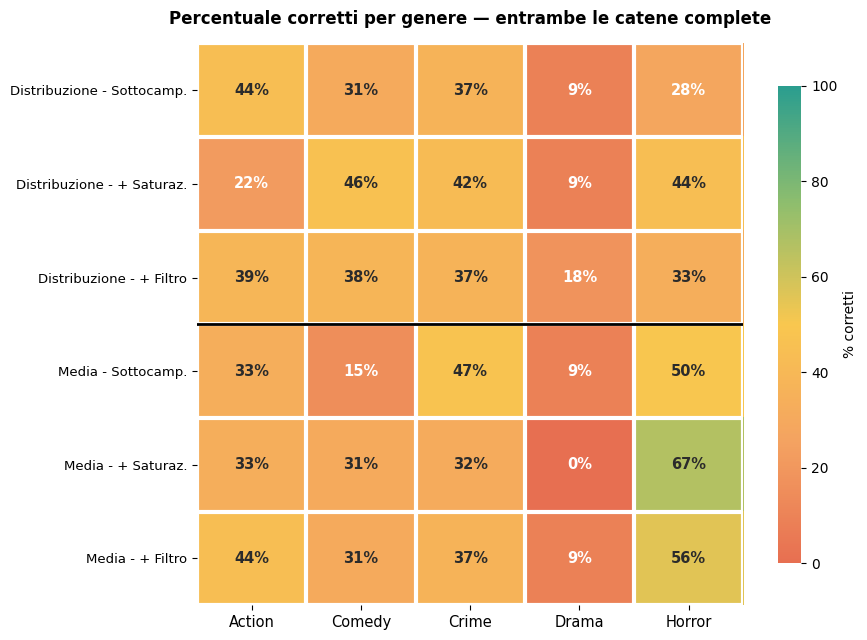

La linea nera orizzontale separa la catena Distribuzione (sopra) dalla
catena Media (sotto). Confronta riga per riga, stesso step, per capire
quale catena mantiene un riconoscimento piu' equilibrato tra i generi.


In [ ]:
# Heatmap combinata: tutti gli step di entrambe le catene, stessi generi in colonna
matrici_confronto = {
    "Distribuzione - Sottocamp.": cm_base_fase3,
    "Distribuzione - + Saturaz.": cm_saturazione,
    "Distribuzione - + Filtro": cm_filtro,
    "Media - Sottocamp.": cm_base_fase3_media,
    "Media - + Saturaz.": cm_saturazione_media,
    "Media - + Filtro": cm_filtro_media,
}

generi_confronto = sorted(cm_base_fase3.index.tolist())
righe_confronto = []
for nome, cm in matrici_confronto.items():
    riga = []
    for g in generi_confronto:
        totale = cm.loc[g].sum()
        corretti = cm.loc[g, g]
        riga.append((corretti / totale * 100) if totale > 0 else 0)
    righe_confronto.append(riga)
dati_confronto = np.array(righe_confronto)

fig, ax = plt.subplots(figsize=(9, 6.5))
im = ax.imshow(dati_confronto, cmap=CMAP_CUSTOM, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(generi_confronto)))
ax.set_xticklabels(generi_confronto, fontsize=10.5)
ax.set_yticks(range(len(matrici_confronto)))
ax.set_yticklabels(list(matrici_confronto.keys()), fontsize=9.5)
ax.set_xticks(np.arange(-0.5, len(generi_confronto), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(matrici_confronto), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="minor", size=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(len(matrici_confronto)):
    for j in range(len(generi_confronto)):
        valore = dati_confronto[i, j]
        colore_testo = "white" if valore < 30 or valore > 80 else "#2b2b2b"
        ax.text(j, i, f"{valore:.0f}%", ha="center", va="center", color=colore_testo, fontsize=10.5, fontweight="bold")
ax.axhline(2.5, color="black", linewidth=2)
ax.set_title("Percentuale corretti per genere — entrambe le catene complete", fontsize=12, fontweight="bold", pad=14)
cbar = fig.colorbar(im, ax=ax, label="% corretti", shrink=0.85)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_confronto_catene.png", dpi=100, bbox_inches="tight")
plt.show()

print("La linea nera orizzontale separa la catena Distribuzione (sopra) dalla")
print("catena Media (sotto). Confronta riga per riga, stesso step, per capire")
print("quale catena mantiene un riconoscimento piu' equilibrato tra i generi.")

## Movie barcodes

I barcode sono visualizzazioni, indipendenti da quale catena di feature
e' stata scelta per il classificatore: leggono sempre `mean_colour` da
MongoDB per tutti i 133 film.

In [ ]:
load_dotenv("../.env", override=True)
mongo_uri = os.getenv("MONGO_URI")
client = MongoClient(mongo_uri)
db = client["color_in_motion"]
frames_collection = db["frames"]

barcode_per_film = {}
for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    documenti = frames_collection.find({"tconst": tconst}).sort("secondo", 1)
    colori_sequenza = []
    for doc in documenti:
        colori_sequenza.append(doc["mean_colour"])
    barcode_per_film[tconst] = colori_sequenza

print("Barcode raccolti:", len(barcode_per_film))

Barcode raccolti: 133


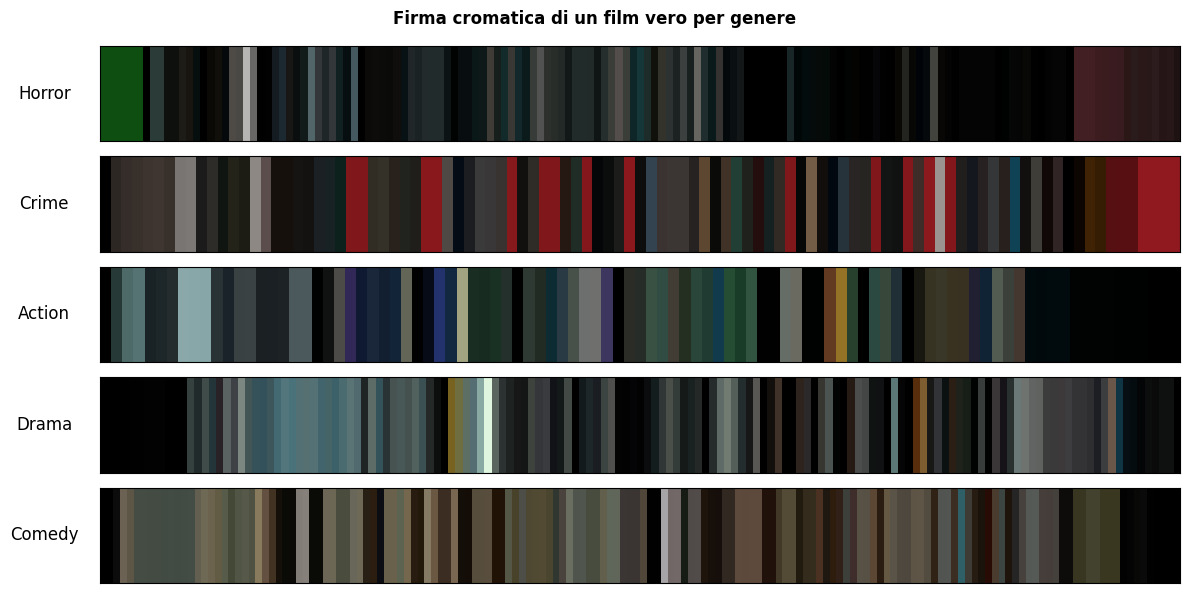

UN film vero (il piu' vicino alla media del genere), colori reali,
senza mediare con altri film - piu' vivido di un barcode medio.


In [42]:
def normalizza_lunghezza(colori, n_punti=100):
    colori = np.array(colori)
    indici_originali = np.linspace(0, len(colori) - 1, len(colori))
    indici_nuovi = np.linspace(0, len(colori) - 1, n_punti)
    risultato = np.zeros((n_punti, 3))
    for canale in range(3):
        risultato[:, canale] = np.interp(indici_nuovi, indici_originali, colori[:, canale])
    return risultato

generi_lista = ["Horror", "Crime", "Action", "Drama", "Comedy"]

film_esemplari = {}
for genere in generi_lista:
    gruppo = colori_df[colori_df["genere_principale"] == genere].copy()
    media_genere = gruppo["brightness_media"].mean()
    gruppo["distanza"] = (gruppo["brightness_media"] - media_genere).abs()
    esemplare = gruppo.sort_values("distanza").iloc[0]
    film_esemplari[genere] = esemplare["tconst"]

fig, axes = plt.subplots(len(generi_lista), 1, figsize=(12, 6))
for i, genere in enumerate(generi_lista):
    tconst = film_esemplari[genere]
    colori = barcode_per_film[tconst]
    immagine = np.array(colori).reshape(1, len(colori), 3)
    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    axes[i].set_ylabel(genere, rotation=0, labelpad=40, va="center", fontsize=12)
plt.suptitle("Firma cromatica di un film vero per genere", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/barcode_representative.png", dpi=120, bbox_inches="tight")
plt.show()

print("UN film vero (il piu' vicino alla media del genere), colori reali,")
print("senza mediare con altri film - piu' vivido di un barcode medio.")

#### Lo stesso barcode, senza i frame-cartello

Horror - tt3289956 - frame scartati: 16 su 151
Crime - tt0114814 - frame scartati: 13 su 101
Action - tt0499549 - frame scartati: 15 su 97
Drama - tt1454468 - frame scartati: 20 su 149
Comedy - tt4925292 - frame scartati: 12 su 160


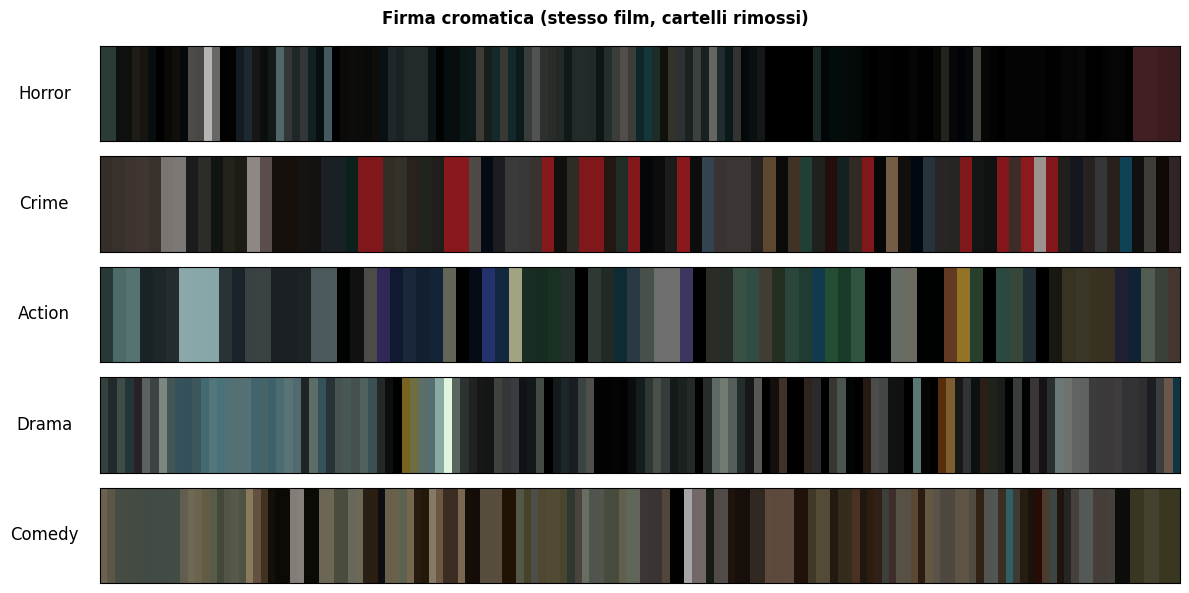


Confronta con il barcode precedente (stesso film): se i cartelli
erano pochi secondi, la differenza visiva sara' minima.


In [43]:
# ricalcoliamo il barcode SOLO per i 5 film esemplari, togliendo i cartelli
# (indipendente dalla catena del classificatore - stesso criterio adattivo sopra)
barcode_esemplari_filtrato = {}

for genere, tconst in film_esemplari.items():
    nome_file = tconst + ".mp4"
    percorso = cartella + "/" + nome_file

    frames = extract_frames(percorso, per_second=1)
    _, _, _, colours = curve_from_frames(frames)
    indici_cartello = trova_frame_cartello(frames)

    colori_puliti = []
    for i in range(len(frames)):
        if i not in indici_cartello:
            colori_puliti.append(colours[i])
    if len(colori_puliti) == 0:
        colori_puliti = colours

    barcode_esemplari_filtrato[genere] = colori_puliti
    print(genere, "-", tconst, "- frame scartati:", len(indici_cartello), "su", len(frames))

fig, axes = plt.subplots(len(generi_lista), 1, figsize=(12, 6))
for i, genere in enumerate(generi_lista):
    colori = barcode_esemplari_filtrato[genere]
    immagine = np.array(colori).reshape(1, len(colori), 3)
    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    axes[i].set_ylabel(genere, rotation=0, labelpad=40, va="center", fontsize=12)
plt.suptitle("Firma cromatica (stesso film, cartelli rimossi)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/barcode_representative_filtered.png", dpi=120, bbox_inches="tight")
plt.show()

print()
print("Confronta con il barcode precedente (stesso film): se i cartelli")
print("erano pochi secondi, la differenza visiva sara' minima.")

## Riepilogo finale: cosa dicono le confusion matrix

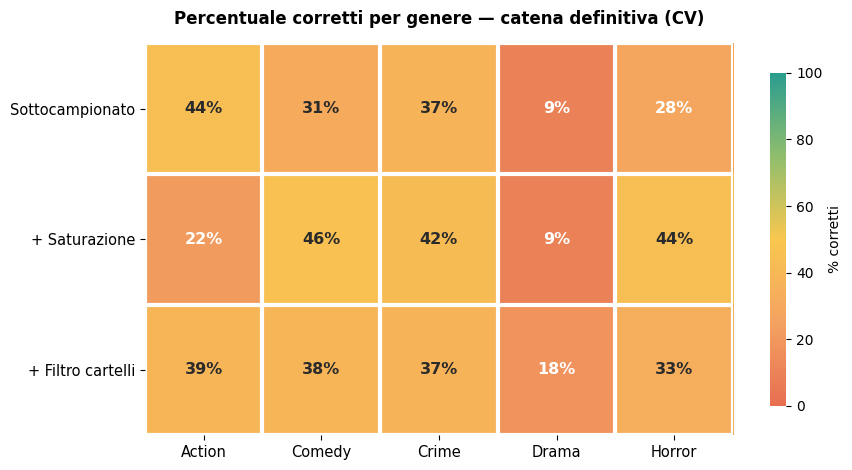

Come leggere: ogni riga e' un passo della costruzione del modello,
ogni colonna un genere. Le percentuali vengono da confusion matrix
aggregate su 5 fold di CV, quindi coprono tutti i 79 film
del sottoinsieme (ognuno usato come test esattamente una volta), non
solo un quarto di essi come nella versione a singolo split.

Nota metodologica: questa catena usa 79 film (Action ridotto a 18),
non tutti i 133 - scelta deliberata per non far dominare Action,
al costo di un campione piu' piccolo.


In [ ]:
matrici = {
    "Sottocampionato": cm_base_fase3,
    "+ Saturazione": cm_saturazione,
    "+ Filtro cartelli": cm_filtro,
}

generi_heatmap = sorted(cm_base_fase3.index.tolist())
righe_heatmap = []
for nome, cm in matrici.items():
    riga = []
    for g in generi_heatmap:
        totale_genere = cm.loc[g].sum()
        corretti = cm.loc[g, g]
        pct = (corretti / totale_genere * 100) if totale_genere > 0 else 0
        riga.append(pct)
    righe_heatmap.append(riga)

dati_heatmap = np.array(righe_heatmap)

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(dati_heatmap, cmap=CMAP_CUSTOM, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(generi_heatmap)))
ax.set_xticklabels(generi_heatmap, fontsize=10.5)
ax.set_yticks(range(len(matrici)))
ax.set_yticklabels(list(matrici.keys()), fontsize=10.5)
ax.set_xticks(np.arange(-0.5, len(generi_heatmap), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(matrici), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="minor", size=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(matrici)):
    for j in range(len(generi_heatmap)):
        valore = dati_heatmap[i, j]
        colore_testo = "white" if valore < 30 or valore > 80 else "#2b2b2b"
        ax.text(j, i, f"{valore:.0f}%", ha="center", va="center", color=colore_testo,
                 fontsize=11.5, fontweight="bold")

ax.set_title("Percentuale corretti per genere — catena definitiva (CV)", fontsize=12, fontweight="bold", pad=14)
cbar = fig.colorbar(im, ax=ax, label="% corretti", shrink=0.85)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_summary.png", dpi=100, bbox_inches="tight")
plt.show()

print("Come leggere: ogni riga e' un passo della costruzione del modello,")
print("ogni colonna un genere. Le percentuali vengono da confusion matrix")
print("aggregate su", n_splits_sicuro, "fold di CV, quindi coprono tutti i 79 film")
print("del sottoinsieme (ognuno usato come test esattamente una volta), non")
print("solo un quarto di essi come nella versione a singolo split.")
print()
print("Nota metodologica: questa catena usa 79 film (Action ridotto a 18),")
print("non tutti i 133 - scelta deliberata per non far dominare Action,")
print("al costo di un campione piu' piccolo.")